In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
L = 1e-4 #device length (m)
N = 1000 #number of grid points
x = np.linspace(0,L,N)
dx = x[1] - x[0]

In [4]:
PERMITTIVITY = 8.854e-12 
epsilon = 11.7 * PERMITTIVITY #permitivitty of silicon
rho = 1e-8  #charge density

Poisson's equation 
$$\frac{d^2 V}{dx^2} = -\frac{\rho}{\epsilon}$$
is discretized using the central finite-differences approximation
$$\frac{V_{i-1} - 2V_i + V_{i+1}}{\Delta x^2}$$
to produce a linear system $$AV = b$$

In [5]:
A = np.zeros((N,N))
for i in range(1, N-1):
    A[i,i-1] = 1
    A[i,i] = -2
    A[i, i+1] = 1
A = A/(dx**2)

In [6]:
#RHS of poisson's equation
b = np.full(N, -rho/epsilon)

The potential is fixed to 0 at both boundaries:
$$V(0) = V(L) = 0

In [ ]:
#boundary conditions
A[0,:] = 0
A[0,0] = 1
A[-1,:] = 0
A[-1,-1] = 1
b[0] = 0
b[-1] = 0

The analytical solution is given by:
$$V_{analytical} = \frac{\rho}{2\epsilon}x(L-x)

In [ ]:
V = np.linalg.solve(A,b) #numerical solution
V_analytical = (rho/(2*epsilon))*x*(L-x)

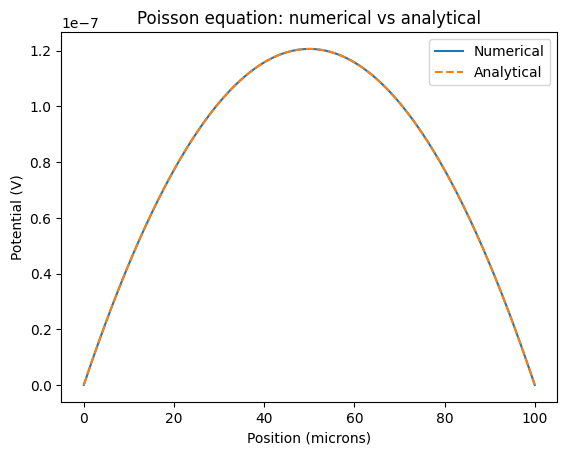

In [10]:
plt.figure()
plt.plot(x*1e6, V, label = "Numerical")
plt.plot(x*1e6, V_analytical, "--", label = "Analytical")
plt.xlabel("Position (microns)")
plt.ylabel("Potential (V)")
plt.legend()
plt.title("Poisson equation: numerical vs analytical")
plt.show()